[ 2 17 67 77 82 92]


Text(0.5, 0, 's')

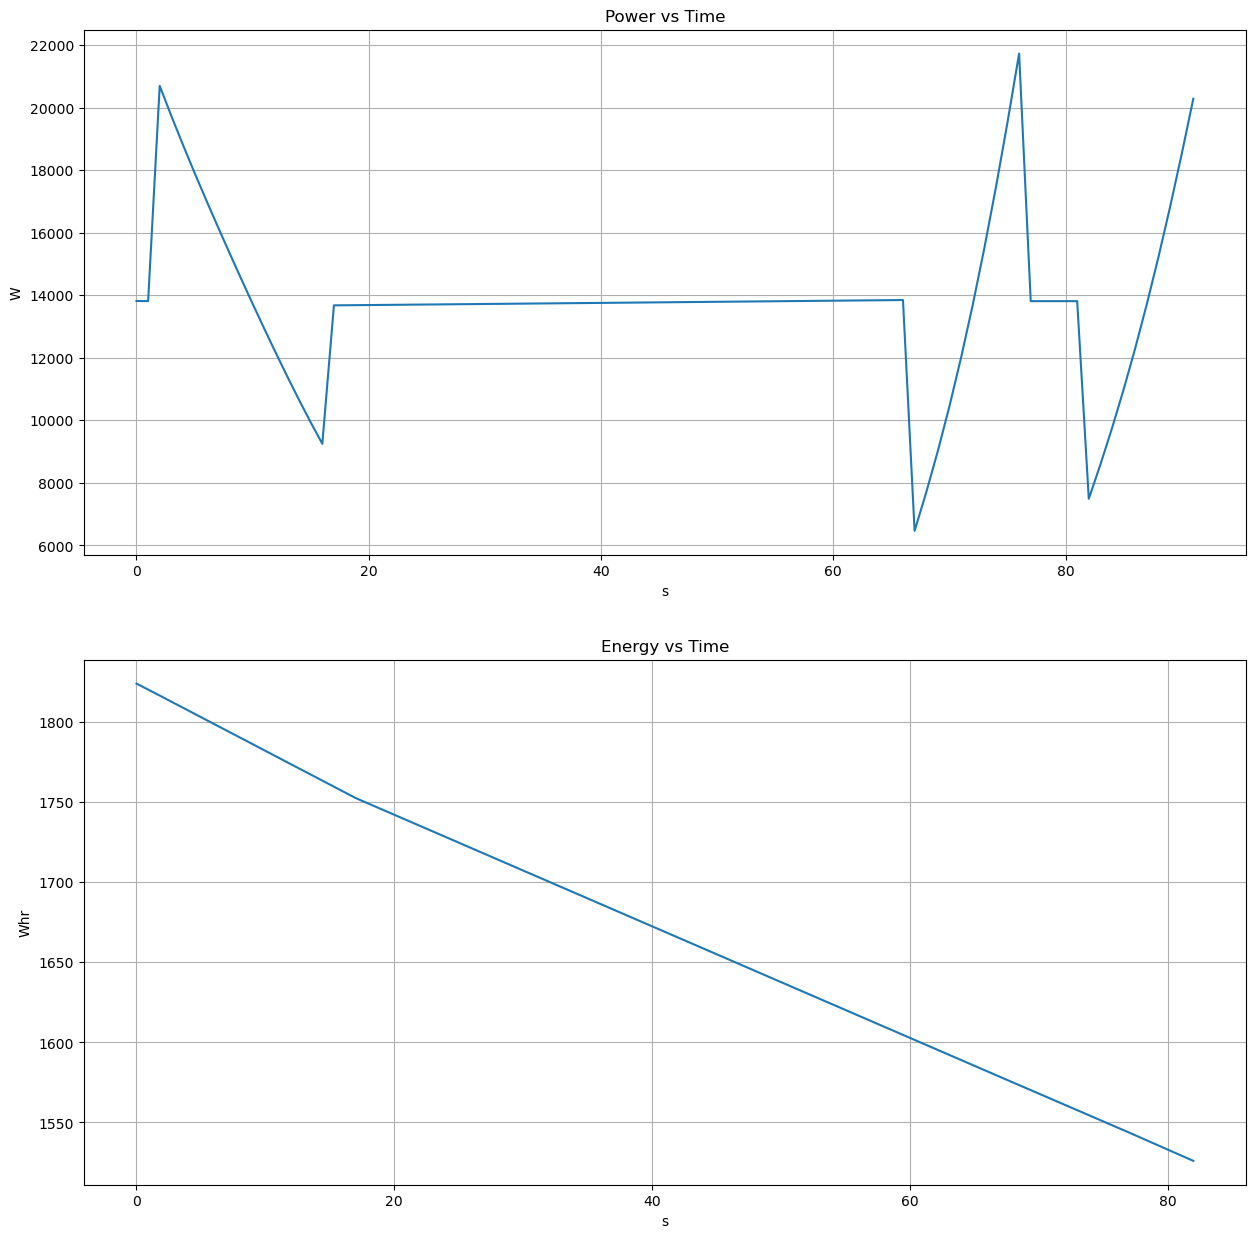

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces

drag_coeff = 0.256

# Mass Analysis Setup
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))
arm_beam = BeamType("annulus", [29, 25], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [14, 12], "Aluminum7075-T6", "strut_beam")
d1 = DroneGeometry("drone_test", 1000, 660, 8, arm_beam, strut_beam, [battery_1, battery_2])
d1_mass = DroneMass(d1)

# Mass Analysis results
total_mass = d1_mass.total_mass + (70 * 10 ** -3)
surface_area = d1.projected_surface_area

# Mission Profile generation
m1 = MissionProfile("m1", 1, 1, 0)
m1.add_segment("takeoff",2,0,2,0,1)
m1.add_segment("climb",15,550000,100000,300,1000)
m1.add_segment("cruise",50,2000000,110000,300,0)
m1.add_segment("descent",10,2200000,50000,0,0)
m1.add_segment("loiter",5,2200000,50000,0,0)
m1.add_segment("land",10,1200000,0,0,0)

# Drone Force Analysis
d1_forces = DroneForces(total_mass, surface_area, drag_coeff, m1)

# Drone
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)
drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)


# Creating Power Plot Data
power_list = np.zeros(m1.t_values[-1])
time_list = np.arange(m1.t_values[-1])
for t in time_list:
    power_list[t] = drone_power.power_at_time(t)

print(m1.t_values[1:])
time_ec, energy_consumption = drone_power.energy_consumption(400, m1.t_values)


# Plotting
fig, axs = plt.subplots(2,1)

fig.set_figheight(15)
fig.set_figwidth(15)


axs[0].set_title("Power vs Time")
axs[0].plot(time_list, power_list / 1000)
axs[0].grid()
axs[0].set_ylabel("W")
axs[0].set_xlabel("s")


axs[1].set_title("Energy vs Time")
axs[1].plot(time_ec, energy_consumption / 3600000)
axs[1].grid()
axs[1].set_ylabel("Whr")
axs[1].set_xlabel("s")